In [1]:
!pip install opendatasets --quiet
import opendatasets as od
dataset_url = 'https://www.kaggle.com/datasets/mssmartypants/rice-type-classification'
od.download(dataset_url)


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Muhammad Musharraf
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 44.3MB/s]

In [2]:
import torch # Torch main framework
import torch.nn as nn # Used for getting the NN Layers
from torch.optim import Adam # Adam Optimizer
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creatning the objects
from torchsummary import summary # Visualize the model layers and number of parameters
from sklearn.model_selection import train_test_split # Split the dataset (train, validation, test)
from sklearn.metrics import accuracy_score # Calculate the testing Accuracy
import matplotlib.pyplot as plt # Plotting the training progress at the end
import pandas as pd # Data reading and preprocessing
import numpy as np # Mathematical operations

device = 'cuda' if torch.cuda.is_available() else 'cpu' # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print(device)

cuda


In [3]:
df=pd.read_csv('/content/rice-type-classification/riceClassification.csv')
df.head()


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.drop(['id'],inplace=True,axis=1)

In [7]:
df.shape

(18185, 11)

In [8]:
print("Output Posibilities:",df['Class'].unique())

Output Posibilities: [1 0]


In [9]:
df['Class'].value_counts()

,count
Class,
1,9985
0,8200


In [10]:
df.isnull().sum()

,0
Area,0
MajorAxisLength,0
MinorAxisLength,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Perimeter,0
Roundness,0
AspectRation,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             18185 non-null  int64  
 1   MajorAxisLength  18185 non-null  float64
 2   MinorAxisLength  18185 non-null  float64
 3   Eccentricity     18185 non-null  float64
 4   ConvexArea       18185 non-null  int64  
 5   EquivDiameter    18185 non-null  float64
 6   Extent           18185 non-null  float64
 7   Perimeter        18185 non-null  float64
 8   Roundness        18185 non-null  float64
 9   AspectRation     18185 non-null  float64
 10  Class            18185 non-null  int64  
dtypes: float64(8), int64(3)
memory usage: 1.5 MB


In [12]:
df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
count,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000
mean,7036.492989,151.680754,59.807851,0.915406,7225.817872,94.132952,0.616653,351.606949,0.707998,2.599081,0.549079
std,1467.197150,12.376402,10.061653,0.030575,1502.006571,9.906250,0.104389,29.500620,0.067310,0.434836,0.497599
min,2522.000000,74.133114,34.409894,0.676647,2579.000000,56.666658,0.383239,197.015000,0.174590,1.358128,0.000000
25%,5962.000000,145.675910,51.393151,0.891617,6125.000000,87.126656,0.538530,333.990000,0.650962,2.208527,0.000000
50%,6660.000000,153.883750,55.724288,0.923259,6843.000000,92.085696,0.601194,353.088000,0.701941,2.602966,1.000000
75%,8423.000000,160.056214,70.156593,0.941372,8645.000000,103.559146,0.695664,373.003000,0.769280,2.964101,1.000000
max,10210.000000,183.211434,82.550762,0.966774,11008.000000,114.016559,0.886573,508.511000,0.904748,3.911845,1.000000


In [13]:
original_df=df.copy()  # Creating a copy of the original Dataframe to use to normalize inference

for column in df.columns:
  df[column]= df[column]/df[column].abs().max() # Divide by the maximum of the column which will make max value of each column is 1

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [14]:
X=np.array(df.iloc[:,:-1])  # Get the inputs, all rows and all columns except last column (output)
y=np.array(df.iloc[:,-1])  # Get the ouputs, all rows and last column only (output column)


In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)  # Create the training split

In [16]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size = 0.5) # Create the validation split

In [17]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(12729, 10)
(2728, 10)
(2728, 10)


In [18]:
class dataset(Dataset):
  def __init__(self,X,y):
    self.X=torch.tensor(X,dtype=torch.float32).to(device)
    self.y=torch.tensor(y,dtype=torch.long).to(device)


  def __len__(self):
    return len(self.X)


  def __getitem__(self,index):
    return self.X[index],self.y[index]





In [19]:

BATCH_SIZE = 32
EPOCHS = 10
HIDDEN_NEURONS = 10
LR = 1e-3

In [20]:
training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [21]:
train_loader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle=True)

In [22]:
class MyModel(nn.Module):
    def __init__(self):

        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

In [23]:
model = MyModel().to(device)


In [24]:
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [25]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr= LR)

In [26]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_loss_train = 0
    total_loss_val = 0 # Renamed from total_loss_validation
    total_acc_train = 0
    total_acc_val = 0  # Renamed from total_acc_validation

    # Traing and validation
    for data in train_loader:

      inputs,labels=data
      prediction = model(inputs).squeeze(1)
      batch_loss = criterion(prediction, labels.float())
      total_loss_train += batch_loss.item()

      acc= ((prediction).round() == labels).sum().item()

      total_acc_train += acc

      optimizer.zero_grad()
      batch_loss.backward()
      optimizer.step()


    ## validation
    with torch.no_grad():
      for data in val_loader: # Changed from validation_data to val_loader
        inputs,labels=data
        prediction = model(inputs).squeeze(1)
        batch_loss = criterion(prediction, labels.float())
        total_loss_val += batch_loss.item()

        acc= ((prediction).round() == labels).sum().item()
        total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
    total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))

    print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/1000:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')
    print("="*50)






Epoch no. 1 Train Loss: 0.2279 Train Accuracy: 89.4336 Validation Loss: 0.0354 Validation Accuracy: 97.6540
Epoch no. 2 Train Loss: 0.1093 Train Accuracy: 97.9731 Validation Loss: 0.0144 Validation Accuracy: 98.5337
Epoch no. 3 Train Loss: 0.0525 Train Accuracy: 98.2638 Validation Loss: 0.0083 Validation Accuracy: 98.6804
Epoch no. 4 Train Loss: 0.0347 Train Accuracy: 98.3895 Validation Loss: 0.0059 Validation Accuracy: 98.6804
Epoch no. 5 Train Loss: 0.0273 Train Accuracy: 98.5309 Validation Loss: 0.0048 Validation Accuracy: 98.7170
Epoch no. 6 Train Loss: 0.0234 Train Accuracy: 98.5388 Validation Loss: 0.0042 Validation Accuracy: 98.6804
Epoch no. 7 Train Loss: 0.0212 Train Accuracy: 98.6252 Validation Loss: 0.0038 Validation Accuracy: 98.6804
Epoch no. 8 Train Loss: 0.0198 Train Accuracy: 98.6095 Validation Loss: 0.0038 Validation Accuracy: 98.7170
Epoch no. 9 Train Loss: 0.0189 Train Accuracy: 98.6173 Validation Loss: 0.0036 Validation Accuracy: 98.7903
Epoch no. 10 Train Loss: 0.0

In [28]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in test_loader:
    inputs,labels=data
    prediction = model(inputs).squeeze(1)
    acc= ((prediction).round() == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy is : {round((total_acc_test/X_test.shape[0])*100, 2)}%")

Accuracy is : 98.61%


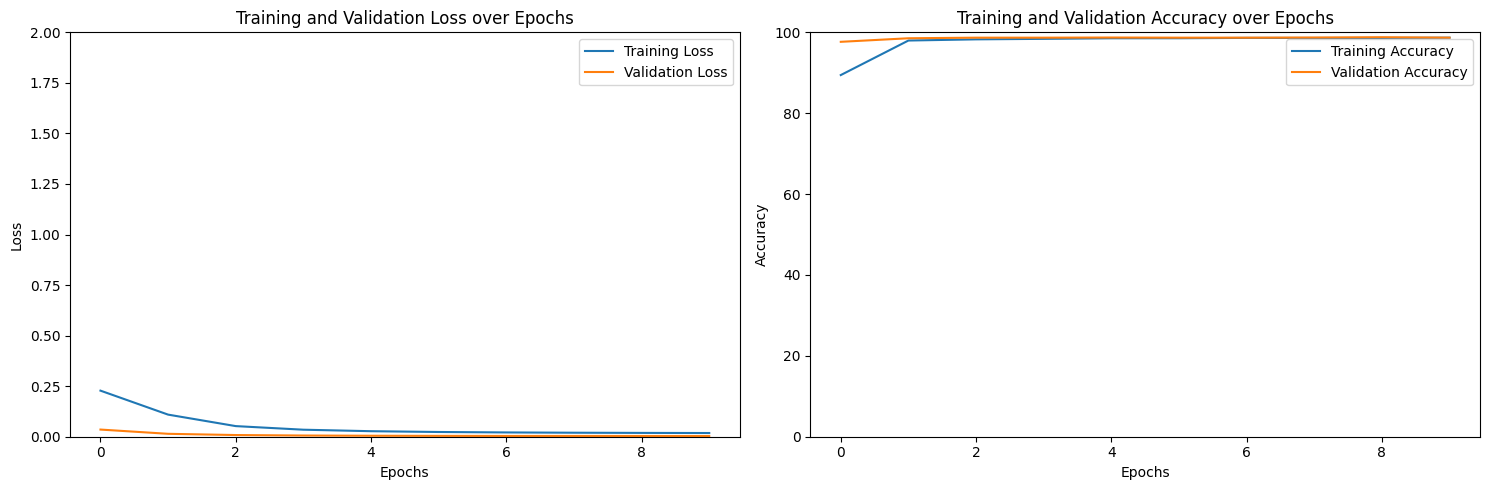

In [29]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()


In [33]:

area = float(input("Area: "))/original_df['Area'].abs().max()
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("EquivDiameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("AspectRation: "))/original_df['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))
print("="*20)
if round(prediction.item()) == 1:
  print("The Rice is Jasmine Rice")
else:
  print("The Rice is Gonen Rice")

Area: 4563
Major Axis Length: 245
Minor Axis Length: 774
Eccentricity: 7465
Convex Area: 4563
EquivDiameter: 473
Extent: 4737
Perimeter: 7367
Roundness: 8363
AspectRation: 663
tensor([1.], device='cuda:0', grad_fn=<SigmoidBackward0>)
Class is:  1
The Rice is Jasmine Rice


In [34]:
# Save Model
torch.save(model.state_dict(), 'Rice_Classification.pth')

In [35]:
# Load model
model = MyModel().to(device)
model.load_state_dict(torch.load('Rice_Classification.pth'))


<All keys matched successfully>

In [36]:
model.eval()

MyModel(
  (input_layer): Linear(in_features=10, out_features=10, bias=True)
  (linear): Linear(in_features=10, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)